# Plot a Pie Chart in Python using Matplotlib

A **Pie Chart** is a circular statistical plot that can display only one series of data. The area of the chart represents the total percentage of the given data. Pie charts are widely used in business presentations, reports, and dashboards due to their simplicity and effectiveness in displaying data distributions.

## Basic Structure and Syntax

### Syntax
```python
matplotlib.pyplot.pie(data, explode=None, labels=None, colors=None, autopct=None, shadow=False)
```

### Parameters
| Parameter | Description |
| :--- | :--- |
| **data** | The array of data values to be plotted. The fractional area of each slice is `data/sum(data)`. |
| **labels** | A list or sequence of strings which sets the label for each wedge. |
| **colors** | Used to provide specific colors to the wedges. |
| **autopct** | A string used to label the wedge with its numerical value (e.g., formatting as a percentage). |
| **shadow** | A boolean used to create a shadow effect for the wedges. |
| **startangle** | Rotates the chart counterclockwise around the x-axis. |
| **wedgeprops** | A dictionary to customize wedge properties like `linewidth` or `edgecolor`. |

## 1. Simple Pie Chart
Creating a basic visualization of car market data.

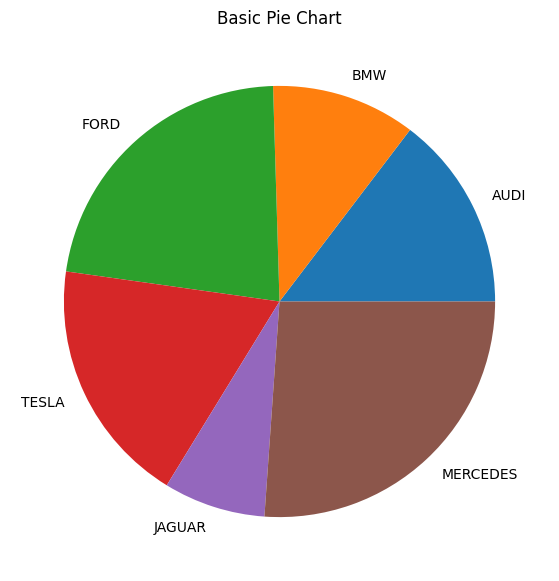

In [1]:
from matplotlib import pyplot as plt
import numpy as np

# Creating dataset
cars = ['AUDI', 'BMW', 'FORD', 'TESLA', 'JAGUAR', 'MERCEDES']
data = [23, 17, 35, 29, 12, 41]

# Creating plot
fig = plt.figure(figsize=(10, 7))
plt.pie(data, labels=cars)

plt.title("Basic Pie Chart")
plt.show()

## 2. Customizing Pie Charts
Adding advanced features like `explode`, `shadow`, custom colors, and percentage labels.

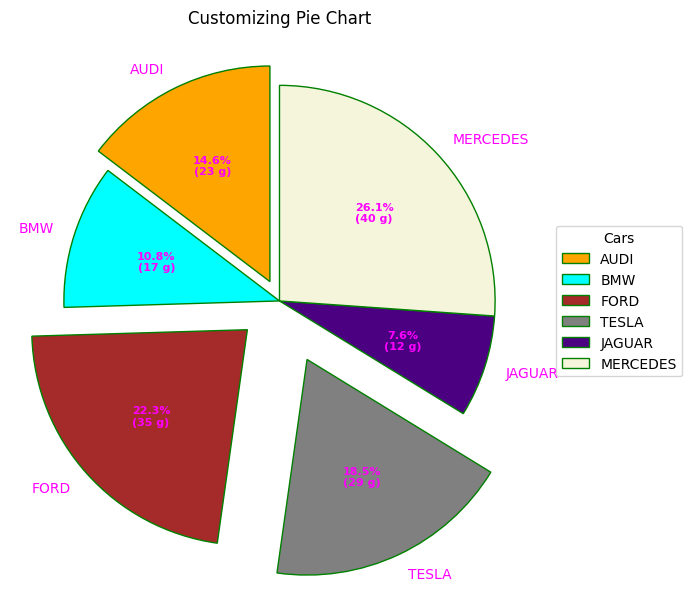

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Creating dataset
cars = ['AUDI', 'BMW', 'FORD', 'TESLA', 'JAGUAR', 'MERCEDES']
data = [23, 17, 35, 29, 12, 41]

# Creating explode data (offsetting specific wedges)
explode = (0.1, 0.0, 0.2, 0.3, 0.0, 0.0)

# Color parameters
colors = ("orange", "cyan", "brown", "grey", "indigo", "beige")

# Wedge properties
wp = {'linewidth': 1, 'edgecolor': "green"}

# Function to display percentage and absolute value
def func(pct, allvalues):
    absolute = int(pct / 100.*np.sum(allvalues))
    return "{:.1f}%\n({:d} g)".format(pct, absolute)

# Creating plot
fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(data, 
                                  autopct=lambda pct: func(pct, data), 
                                  explode=explode, 
                                  labels=cars, 
                                  colors=colors, 
                                  startangle=90, 
                                  wedgeprops=wp, 
                                  textprops=dict(color="magenta"))

# Adding legend
ax.legend(wedges, cars, title="Cars", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.setp(autotexts, size=8, weight="bold")
ax.set_title("Customizing Pie Chart")

plt.show()

## 3. Creating a Nested Pie Chart
Hierarchical data visualization using concentric rings (polar projection).

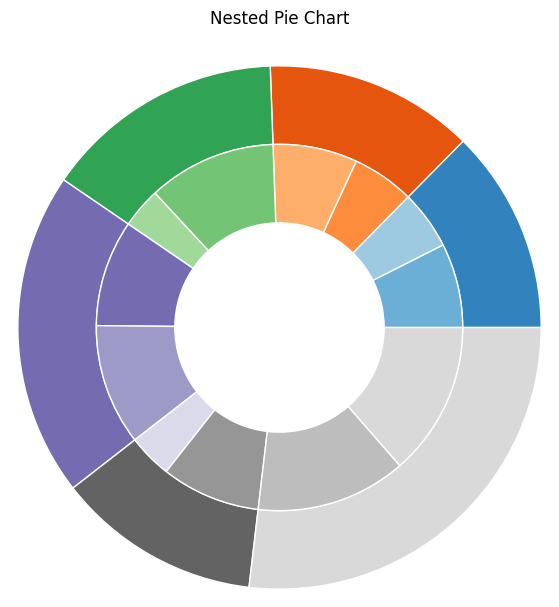

In [3]:
from matplotlib import pyplot as plt
import numpy as np

# Creating dataset
size = 0.3
cars = ['AUDI', 'BMW', 'FORD', 'TESLA', 'JAGUAR', 'MERCEDES']
data = np.array([[23, 16], [17, 23], [35, 11], [29, 33], [12, 27], [41, 42]])

# Normalizing data to 2 pi for polar axes
norm = data / np.sum(data) * 2 * np.pi
left = np.cumsum(np.append(0, norm.flatten()[:-1])).reshape(data.shape)

# Color scale
cmap = plt.get_cmap("tab20c")
outer_colors = cmap(np.arange(6)*4)
inner_colors = cmap(np.array([1, 2, 5, 6, 9, 10, 12, 13, 15, 17, 18, 20]))

# Creating plot using polar projection
fig, ax = plt.subplots(figsize=(10, 7), subplot_kw=dict(polar=True))

# Outer Ring
ax.bar(x=left[:, 0], width=norm.sum(axis=1), bottom=1-size, height=size, 
       color=outer_colors, edgecolor='w', linewidth=1, align="edge")

# Inner Ring
ax.bar(x=left.flatten(), width=norm.flatten(), bottom=1-2*size, height=size, 
       color=inner_colors, edgecolor='w', linewidth=1, align="edge")

ax.set(title="Nested Pie Chart")
ax.set_axis_off()
plt.show()